In [51]:
#importting the libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import seaborn as sns
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsOneClassifier
import warnings
warnings.filterwarnings('ignore')

In [52]:
file_path = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%203/data/drug200.csv'
data = pd.read_csv(file_path)
data.head(10)

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY
5,22,F,NORMAL,HIGH,8.607,drugX
6,49,F,NORMAL,HIGH,16.275,drugY
7,41,M,LOW,HIGH,11.037,drugC
8,60,M,NORMAL,HIGH,15.171,drugY
9,43,M,LOW,NORMAL,19.368,drugY


In [53]:
#print(data.columns)

In [54]:
#data.columns.tolist()

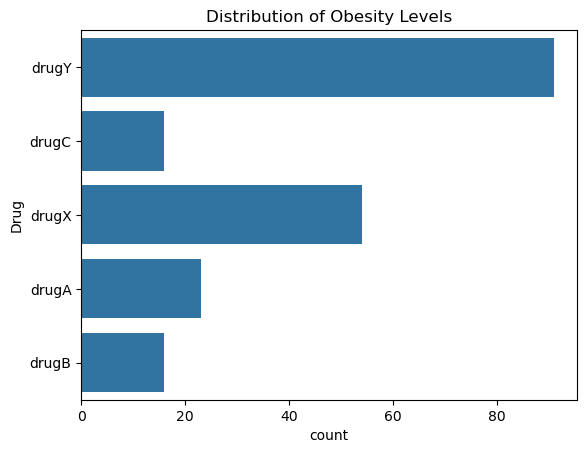

In [55]:
#Distribution of the target variable 
sns.countplot(y='Drug', data=data)
plt.title("Distribution of Obesity Levels")
plt.show()

In [56]:
"""
# Count occurrences of each drug
drug_counts = data['Drug'].value_counts()
# Create horizontal bar chart
plt.barh(drug_counts.index, drug_counts.values)
plt.title("Distribution of Drug Types")
plt.xlabel("Count")
plt.ylabel("Drug")
plt.show()
"""

'\n# Count occurrences of each drug\ndrug_counts = data[\'Drug\'].value_counts()\n# Create horizontal bar chart\nplt.barh(drug_counts.index, drug_counts.values)\nplt.title("Distribution of Drug Types")\nplt.xlabel("Count")\nplt.ylabel("Drug")\nplt.show()\n'

In [57]:
data.describe()

,Age,Na_to_K
count,200.000000,200.000000
mean,44.315000,16.084485
std,16.544315,7.223956
min,15.000000,6.269000
25%,31.000000,10.445500
50%,45.000000,13.936500
75%,58.000000,19.380000
max,74.000000,38.247000


In [58]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


In [59]:
#check missing values

data.isnull().sum()

Age            0
Sex            0
BP             0
Cholesterol    0
Na_to_K        0
Drug           0
dtype: int64

In [60]:
# Select continuous columns
continuous_columns = data.select_dtypes(include=['float64']).columns.tolist()
# Standardize
scaler = StandardScaler()
selected_features = scaler.fit_transform(data[continuous_columns])
# Convert back to DataFrame
scaled_df = pd.DataFrame(selected_features,columns=continuous_columns)
#combining with the original dataset
scaled_data = pd.concat([data.drop(columns = continuous_columns),scaled_df], axis = 1)
scaled_data

,Age,Sex,BP,Cholesterol,Drug,Na_to_K
0,23,F,HIGH,HIGH,drugY,1.286522
1,47,M,LOW,HIGH,drugC,-0.415145
2,47,M,LOW,HIGH,drugC,-0.828558
3,28,F,NORMAL,HIGH,drugX,-1.149963
4,61,F,LOW,HIGH,drugY,0.271794
...,...,...,...,...,...,...
195,56,F,LOW,HIGH,drugC,-0.626917
196,16,M,LOW,HIGH,drugC,-0.565995
197,52,M,NORMAL,HIGH,drugX,-0.859089
198,23,M,NORMAL,NORMAL,drugX,-0.286500


In [61]:
"""
# Select continuous columns
continuous_columns = data.select_dtypes(include=['float64']).columns.tolist()
scaler = StandardScaler()
selected_features = scaler.fit_transform(data[continuous_columns])
scaled_df = pd.DataFrame(selected_features,columns=continuous_columns)
scaled_data = pd.concat([data.drop(columns = continuous_columns),scaled_df], axis = 1)
scaled_data
"""

"\n# Select continuous columns\ncontinuous_columns = data.select_dtypes(include=['float64']).columns.tolist()\nscaler = StandardScaler()\nselected_features = scaler.fit_transform(data[continuous_columns])\nscaled_df = pd.DataFrame(selected_features,columns=continuous_columns)\nscaled_data = pd.concat([data.drop(columns = continuous_columns),scaled_df], axis = 1)\nscaled_data\n"

In [62]:
#to get all the object needs to encode into numbers thats zeros and once binary
categorical_columns = scaled_data.select_dtypes(include = ['object']).columns.tolist()
categorical_columns.remove('Drug')
categorical_columns

['Sex', 'BP', 'Cholesterol']

In [63]:
#Encode them using the OneHotEncoder() function
encoder = OneHotEncoder(sparse_output = False, drop = 'first')
encoded_features = encoder.fit_transform(scaled_data[categorical_columns])


In [64]:
# Convert it from the array form to pandas
encoded_column_names = encoder.get_feature_names_out(categorical_columns)
encoded_df = pd.DataFrame(
    encoded_features,
    columns=encoded_column_names
)

In [65]:
encoded_df

,Sex_M,BP_LOW,BP_NORMAL,Cholesterol_NORMAL
0,0.0,0.0,0.0,0.0
1,1.0,1.0,0.0,0.0
2,1.0,1.0,0.0,0.0
3,0.0,0.0,1.0,0.0
4,0.0,1.0,0.0,0.0
...,...,...,...,...
195,0.0,1.0,0.0,0.0
196,1.0,1.0,0.0,0.0
197,1.0,0.0,1.0,0.0
198,1.0,0.0,1.0,1.0


In [66]:
# Combined it to the targert in the whole dataset
prepped_data = pd.concat([scaled_data.drop(columns = categorical_columns), encoded_df],axis = 1)
prepped_data

,Age,Drug,Na_to_K,Sex_M,BP_LOW,BP_NORMAL,Cholesterol_NORMAL
0,23,drugY,1.286522,0.0,0.0,0.0,0.0
1,47,drugC,-0.415145,1.0,1.0,0.0,0.0
2,47,drugC,-0.828558,1.0,1.0,0.0,0.0
3,28,drugX,-1.149963,0.0,0.0,1.0,0.0
4,61,drugY,0.271794,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...
195,56,drugC,-0.626917,0.0,1.0,0.0,0.0
196,16,drugC,-0.565995,1.0,1.0,0.0,0.0
197,52,drugX,-0.859089,1.0,0.0,1.0,0.0
198,23,drugX,-0.286500,1.0,0.0,1.0,1.0


In [67]:
# Encoding only the target variable into categorical form 
prepped_data['Drug'] = prepped_data['Drug'].astype('category').cat.codes
prepped_data

,Age,Drug,Na_to_K,Sex_M,BP_LOW,BP_NORMAL,Cholesterol_NORMAL
0,23,4,1.286522,0.0,0.0,0.0,0.0
1,47,2,-0.415145,1.0,1.0,0.0,0.0
2,47,2,-0.828558,1.0,1.0,0.0,0.0
3,28,3,-1.149963,0.0,0.0,1.0,0.0
4,61,4,0.271794,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...
195,56,2,-0.626917,0.0,1.0,0.0,0.0
196,16,2,-0.565995,1.0,1.0,0.0,0.0
197,52,3,-0.859089,1.0,0.0,1.0,0.0
198,23,3,-0.286500,1.0,0.0,1.0,1.0


In [68]:
#Seperate the target from the input features
X = prepped_data.drop('Drug',axis = 1)
y = prepped_data['Drug']

In [69]:
#Splitting dataset into training and testting set
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2, random_state = 42,stratify = y)

In [70]:
model_ova = LogisticRegression(multi_class = 'ovr', max_iter = 100)
model_ova.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'ovr'


In [71]:
y_pred_ova = model_ova.predict(X_test)

In [72]:
print(y_pred_ova)

[2 3 0 3 4 4 4 4 4 4 0 4 2 4 3 1 2 3 4 0 3 3 3 4 3 3 0 0 4 4 0 4 1 3 4 4 4
 4 4 4]


In [73]:
y_predd = pd.DataFrame(y_pred_ova)
y_predd.sample(10)

,0
28,4
11,4
36,4
25,3
1,3
16,2
19,0
2,0
8,4
12,2


In [74]:
print(f"Accuracy of the model is {np.round(100*accuracy_score(y_test,y_pred_ova),2)}%")

Accuracy of the model is 95.0%


In [75]:
model_ovo = OneVsOneClassifier(LogisticRegression(max_iter = 100))
model_ovo.fit(X_train,y_train)

,estimator,LogisticRegression()
,n_jobs,None
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'


In [76]:
y_pred_ovo = model_ovo.predict(X_test)

In [77]:
print(y_pred_ovo)

[2 3 0 3 4 4 4 4 4 4 0 4 2 4 3 1 2 3 4 0 3 3 3 4 3 3 0 0 4 4 0 4 3 3 4 4 4
 4 4 4]


In [78]:
print(f" The accuracy of the model ovo is {np.round(100*accuracy_score(y_test,y_pred_ovo),2)}%")

 The accuracy of the model ovo is 92.5%


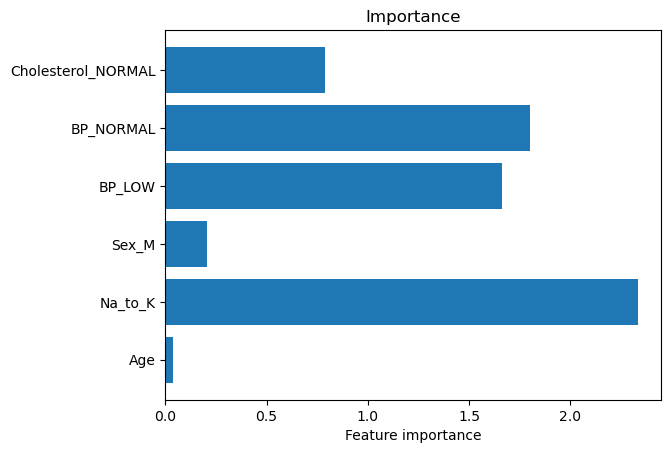

In [82]:
feature_importance = np.mean(np.abs(model_ova.coef_), axis = 0)
plt.barh(X.columns, feature_importance)
plt.xlabel("Feature importance")
plt.title("Importance")
plt.show()

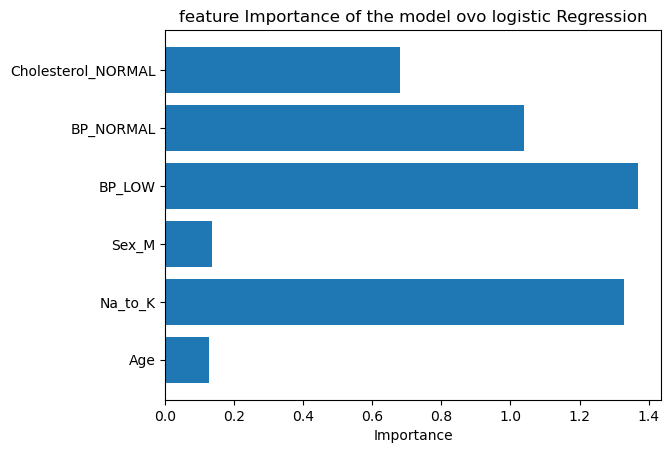

In [84]:
#collect all coefficient from each underlying bunary classifier
coefs = np.array([est.coef_[0] for est in model_ovo.estimators_])
#Now let take mean accross the classifiers
feature_importance = np.mean(np.abs(coefs), axis = 0)
plt.barh(X.columns, feature_importance)
plt.title("feature Importance of the model ovo logistic Regression")
plt.xlabel("Importance")
plt.show()